VGG19 Base Model Tests

In [ ]:
# Mount Google Drive
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Set up dataset path
os.chdir("drive/My Drive/")
spreadsheet_path = "Auslan Static Dataset Breakdown"
dataset_path = "AuslanStaticData"

Mounted at /content/drive


In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

# Sheets access
gc = gspread.authorize(creds)

In [ ]:
import pandas as pd

worksheet = gc.open('Auslan Static Dataset Breakdown').sheet1

# Get all values from the worksheet
rows = worksheet.get_all_values()

# Convert to DataFrame with first row as column names
spreadsheet = pd.DataFrame(rows[1:], columns=rows[0])

print(spreadsheet)

     ID Subject         Date            Device        Filename Class Lighting  \
0     0    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_0_1.jpg     0  Natural   
1     1    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_1_1.jpg     1  Natural   
2     2    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_2_1.jpg     2  Natural   
3     3    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_3_1.jpg     3  Natural   
4     4    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_4_1.jpg     4  Natural   
...  ..     ...          ...               ...             ...   ...      ...   
4729       Nick  Apr 29 2025         iPhone 12  Nick_u_114.JPG     u  Natural   
4730       Nick  Apr 29 2025         iPhone 12  Nick_u_115.JPG     u  Natural   
4731       Nick  Apr 29 2025         iPhone 12  Nick_u_116.JPG     u  Natural   
4732       Nick  Apr 29 2025         iPhone 12  Nick_u_117.JPG     u  Natural   
4733       Nick  Apr 29 2025         iPhone 12  Nick_u_118.JPG     u  Natural   

     Light level           

In [ ]:
# Get list of files
file_list = os.listdir(dataset_path)

# Convert to DataFrame
drive_files = pd.DataFrame(file_list, columns=['Filename'])

set1 = set(drive_files['Filename'])
set2 = set(spreadsheet["Filename"])

# Find missing files
missing_in_df2 = set1 - set2  # Files in df1 but not in df2
missing_in_df1 = set2 - set1  # Files in df2 but not in df1

print("Files missing in Spreadsheet:", missing_in_df2)
print("Files missing in Drive folder:", missing_in_df1)

print(set1)
print(set2)

Files missing in Spreadsheet: set()
Files missing in Drive folder: set()
{'Luke_8_27.jpg', 'Nick_6_79.jpg', 'Luke_9_36.jpg', 'Evelyn_8_65.jpg', 'Nick_7_95.jpg', 'Luke_1_41.JPG', 'Daniel_i_7.jpg', 'Luke_5_17.jpg', 'Evelyn_1_63.jpg', 'Luke_o_17.jpg', 'Luke_3_29.jpg', 'Nick_0_48.jpg', 'Evelyn_u_11.jpg', 'Nick_h_9.jpg', 'Nick_o_50.jpg', 'Luke_b_2.jpg', 'Nick_4_57.jpg', 'Nick_4_74.jpg', 'Daniel_3_44.jpg', 'Nick_1_31.jpg', 'Nick_0_92.jpg', 'Evelyn_q_6.jpg', 'Nick_1_44.jpg', 'Evelyn_0_30.jpg', 'Daniel_7_47.jpg', 'Nick_3_60.jpg', 'Evelyn_0_32.jpg', 'Luke_u_24.jpg', 'Nick_6_36.jpg', 'Evelyn_u_2.jpg', 'Nick_u_4.jpg', 'Luke_9_5.jpg', 'Evelyn_v_2.jpg', 'Nick_1_95.jpg', 'Nick_a_102.jpg', 'Nick_1_27.jpg', 'Nick_9_95.jpg', 'Evelyn_i_65.jpg', 'Evelyn_t_5.jpg', 'Daniel_2_6.jpg', 'Daniel_a_38.jpg', 'Evelyn_a_20.jpg', 'Nick_3_4.jpg', 'Evelyn_o_61.jpg', 'Nick_2_53.jpg', 'Evelyn_6_27.jpg', 'Evelyn_6_55.jpeg', 'Evelyn_9_70.jpg', 'Luke_7_34.jpg', 'Evelyn_u_56.JPG', 'Daniel_0_7.jpg', 'Evelyn_a_16.jpg', 'Evely

In [ ]:
# Create training and testing datasets that include and exclude specific images
import os
import pandas as pd
import shutil

vowel_numbers = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'e', 'i', 'o', 'u']

# Files excluding independent variable
images = spreadsheet[spreadsheet['Class'].isin(vowel_numbers)]

filenames = images["Filename"]

training_images = filenames.sample(frac=0.7)  # Reduced to 70% for training
validation_images = filenames.drop(training_images.index).sample(frac=0.5) # 15% for validation
testing_images = filenames.drop(training_images.index).drop(validation_images.index) # 15% for testing


In [ ]:
# Extract classes from filenames

import re

def class_finder(filename):
    match = re.search(r'_(\w)_', filename)  # Extract the character between underscores
    if not match:
        raise ValueError("Filename format incorrect. Expected format: 'prefix_<char>_suffix'")

    extractFileClass = match.group(1)  # Get the matched class

    # Mapping for vowels
    class_map = {'a': 10, 'e': 11, 'i': 12, 'o': 13, 'u': 14}

    # Check if it's a digit
    if extractFileClass.isdigit():
        return int(extractFileClass)  # Convert string number to int
    elif extractFileClass in class_map:
        return class_map[extractFileClass]  # Map vowel to number
    else:
        raise ValueError(f"Unknown class: {extractFileClass}")  # Handle invalid cases

def label_generator(dataset_filenames):
    labels = []
    for filename in dataset_filenames:
        labels.append(class_finder(filename))
    return labels


In [ ]:
import tensorflow as tf

label_training = label_generator(training_images)
label_validation = label_generator(validation_images) # Generate validation labels
label_testing = label_generator(testing_images)

label_training = tf.keras.utils.to_categorical(label_training, num_classes=15)
label_validation = tf.keras.utils.to_categorical(label_validation, num_classes=15) # One-hot encode validation labels
label_testing = tf.keras.utils.to_categorical(label_testing, num_classes=15)

In [ ]:
# Create TF datasets from PD dataframes
def load_image(image_path):
    img = tf.io.read_file(os.path.join("AuslanStaticData", image_path.numpy().decode())) # Decode the image path from bytes to string
    img = tf.image.decode_jpeg(img, channels=3) # Decode the image
    img = tf.image.resize(img, [224, 224]) # Resize the image to your desired size
    img = tf.cast(img, tf.float32) # Cast the image to float32
    img = img / 255.0 # Normalize the pixel values to [0, 1]
    return img

def load_image_wrapper(image_path):
    img = tf.py_function(load_image, [image_path], Tout=tf.float32)
    img.set_shape([224, 224, 3])  # Set the shape immediately
    return img


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

training = tf.data.Dataset.from_tensor_slices((training_images.values, label_training)) # Create a dataset from the paths and labels
training = training.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
training = training.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

validation = tf.data.Dataset.from_tensor_slices((validation_images.values, label_validation))
validation = validation.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation = validation.batch(32).prefetch(tf.data.AUTOTUNE)

testing = tf.data.Dataset.from_tensor_slices((testing_images.values, label_testing)) # Create a dataset from the paths and labels
testing = testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
testing = testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching


In [ ]:
# Augment training datasets
flip_dataset = training.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
brightness_dataset = training.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.1), label))
contrast_dataset = training.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
saturation_dataset = training.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))

training = tf.data.Dataset.sample_from_datasets([training, flip_dataset, brightness_dataset, contrast_dataset, saturation_dataset])


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras import layers, models, regularizers # Import regularizers here
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model = VGG19(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model.trainable = True

# Optionally freeze most of the base model
for layer in base_model.layers[:-4]:  # or try -6, -8
    layer.trainable = False

# Define model_no_var with its own base model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

learning_rate = 0.00016043268

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_1 = EarlyStopping(monitor='val_accuracy', mode='max', patience=10,  restore_best_weights=True)
model.fit(training, epochs=200, batch_size=32,validation_data=validation, callbacks=[es_1])

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/200
    459/Unknown 241s 474ms/step - accuracy: 0.1354 - loss: 3.2861

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


460/460 ━━━━━━━━━━━━━━━━━━━━ 254s 501ms/step - accuracy: 0.1359 - loss: 3.2839 - val_accuracy: 0.4832 - val_loss: 1.8884
Epoch 2/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 93s 202ms/step - accuracy: 0.6345 - loss: 1.4681 - val_accuracy: 0.7376 - val_loss: 1.1592
Epoch 3/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 93s 201ms/step - accuracy: 0.8684 - loss: 0.8409 - val_accuracy: 0.7264 - val_loss: 1.2659
Epoch 4/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 93s 201ms/step - accuracy: 0.9267 - loss: 0.6317 - val_accuracy: 0.7616 - val_loss: 1.1543
Epoch 5/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 93s 201ms/step - accuracy: 0.9571 - loss: 0.5079 - val_accuracy: 0.7536 - val_loss: 1.1831
Epoch 6/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 93s 201ms/step - accuracy: 0.9683 - loss: 0.4412 - val_accuracy: 0.7744 - val_loss: 1.1821
Epoch 7/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 93s 201ms/step - accuracy: 0.9731 - loss: 0.3836 - val_accuracy: 0.7600 - val_loss: 1.1988
Epoch 8/200
460/460 ━━━━━━━━━━━━━━━━━━━━ 93s 202ms/step - accuracy: 0.9779 - loss: 0.33

In [ ]:
# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set using the model
pred_1 = model.predict(testing, verbose=1)

# Get the predicted labels by taking the index of the maximum probability for each image
pred_1_labels = np.argmax(pred_1, axis=1)

# Get the true labels from the test set generator
pred_1_true = np.concatenate([y.numpy() for _, y in testing.unbatch()])

# Reshape into (N, 15) where N is inferred
pred_1_true = pred_1_true.reshape(-1, 15)

# Apply argmax to get class labels
pred_1_true = np.argmax(pred_1_true, axis=1)

# Generate the confusion matrix
cm_1 = confusion_matrix(pred_1_true, pred_1_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 521ms/step


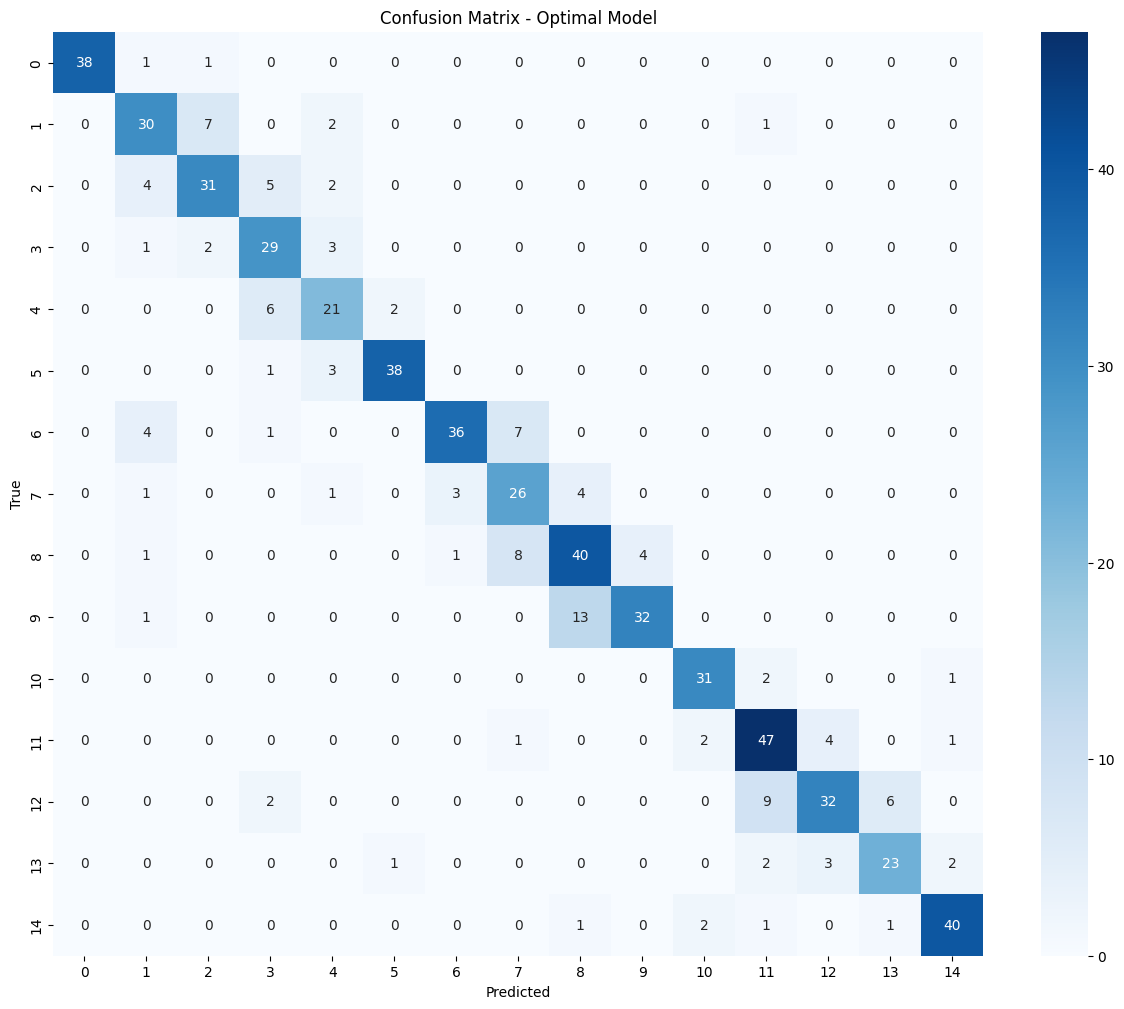

In [ ]:
# Define the confusion matrices and titles for plotting
confusion_matrices = [cm_1]
titles = ['Optimal Model']

# Generate the confusion matrix
cm_1 = confusion_matrix(pred_1_true, pred_1_labels)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(15, 12))  # Adjust figure size as needed
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(cm_1.shape[1])],
            yticklabels=[str(i) for i in range(cm_1.shape[0])])
plt.title('Confusion Matrix - Optimal Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
print("Optimal Model")
print(classification_report(pred_1_true, pred_1_labels))

Optimal Model
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        40
           1       0.70      0.75      0.72        40
           2       0.76      0.74      0.75        42
           3       0.66      0.83      0.73        35
           4       0.66      0.72      0.69        29
           5       0.93      0.90      0.92        42
           6       0.90      0.75      0.82        48
           7       0.62      0.74      0.68        35
           8       0.69      0.74      0.71        54
           9       0.89      0.70      0.78        46
          10       0.89      0.91      0.90        34
          11       0.76      0.85      0.80        55
          12       0.82      0.65      0.73        49
          13       0.77      0.74      0.75        31
          14       0.91      0.89      0.90        45

    accuracy                           0.79       625
   macro avg       0.80      0.79      0.79       625
weighted avg